# Experiments and Results

Alternative coordination rules, null-model comparisons, and counts of socially unrealized analog encounters are evaluated at week 52. All quantities are generated by the simulation; they do not reconstruct the operator’s observed customer network.


In [7]:
from pathlib import Path
import sys

# notebook runs from analysis and setting up project imports
sys.path.insert(0, str(Path.cwd().resolve().parent / "analysis"))
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))
from notebook_paths import ensure_src_on_path

PROJECT_ROOT = ensure_src_on_path()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## Coordination scenarios and familiarity breadth


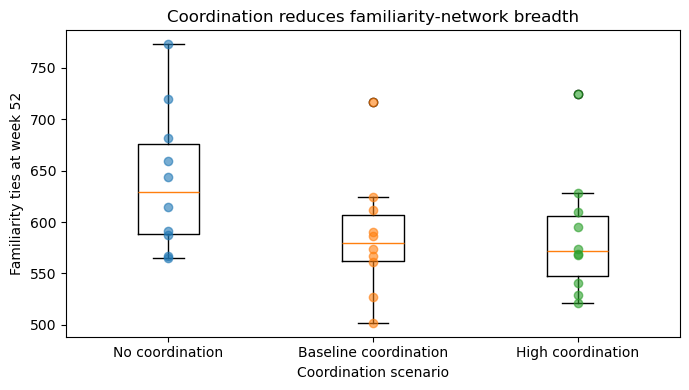

In [8]:
from soulcycle_network.analysis.io import load_master_table

master = load_master_table(OUTPUT_DIR)
final = master[(master["week"] == 52) & (master["network_type"] == "familiarity")]

order = ["no_coordination", "baseline", "high_coordination"]
labels = ["No coordination", "Baseline coordination", "High coordination"]
data = [final[final["scenario"] == s]["edges"].values for s in order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(data, tick_labels=labels)
# overlay individual seeds
for i, ys in enumerate(data):
    ax.scatter(np.full(len(ys), i + 1), ys, alpha=0.6, zorder=3)
ax.set_xlabel("Coordination scenario")
ax.set_ylabel("Familiarity ties at week 52")
ax.set_title("Coordination reduces familiarity-network breadth")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_coordination_scenarios.png", dpi=150, bbox_inches="tight")
plt.show()

Total familiarity ties at week 52 are generally higher under no coordination than under baseline or high coordination, with individual seeds shown as points. When riders repeatedly attend with established partners, attendance patterns concentrate and opportunities for new recurring co-attendance decline (reducing breadth rather than necessarily strengthening remaining ties or accelerating social conversion). The contrast follows from encoded coordination rules, not from field data on rider behavior.


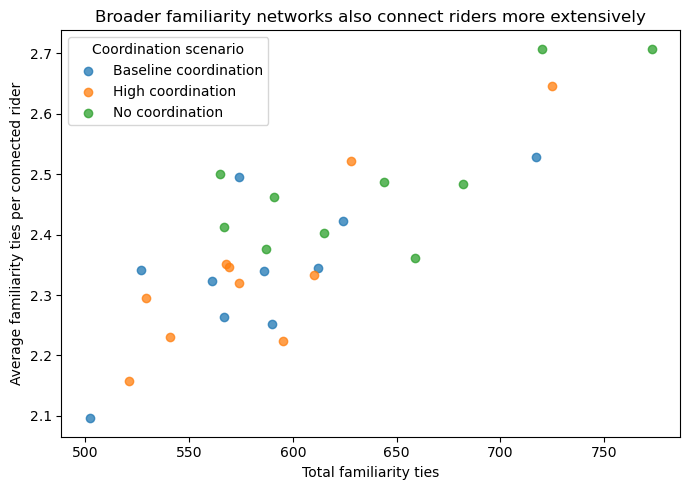

In [9]:
scenario_labels = {"no_coordination": "No coordination","baseline": "Baseline coordination","high_coordination": "High coordination"}

fig, ax = plt.subplots(figsize=(7, 5))
for scenario, sub in final.groupby("scenario"):
    ax.scatter(sub["edges"],sub["mean_degree_connected_subgraph"],label=scenario_labels.get(scenario, scenario),alpha=0.75)
ax.set_xlabel("Total familiarity ties")
ax.set_ylabel("Average familiarity ties per connected rider")
ax.legend(title="Coordination scenario")
ax.set_title("Broader familiarity networks also connect riders more extensively")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_breadth_vs_mean_degree.png", dpi=150, bbox_inches="tight")
plt.show()

Seeds with more familiarity ties at week 52 also tend to exhibit higher mean familiarity degree among connected riders, and no-coordination runs often occupy the upper-right of the plot. Mean degree counts distinct partners, not tie strength or persistence, so the pattern should not be read as a validated breadth–depth tradeoff. Coordination scenarios do not systematically offset lower tie counts with higher mean degree on this measure.


## Latent analog connections (week 52, baseline, seed 6400)


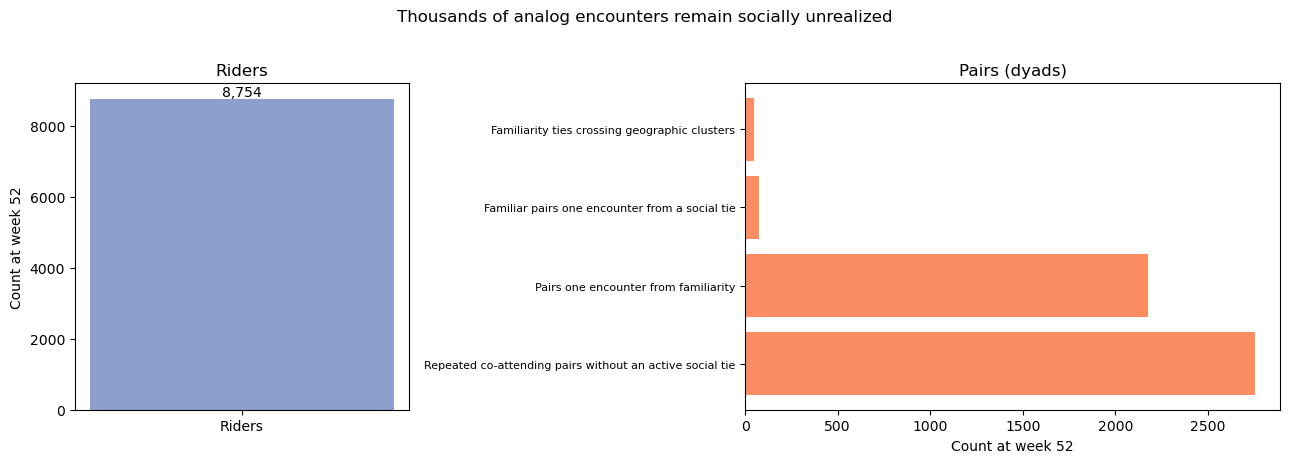

In [10]:
row = master[(master["scenario"]=="baseline")&(master["seed"]==6400)&(master["network_type"]=="familiarity")&(master["week"] == 52)].iloc[0]

# pair-level latent counts vs single rider-level count
pair_specs = [
    ("latent_repeated_co_not_social_dyads", "Repeated co-attending pairs without an active social tie"),
    ("latent_pairs_one_encounter_from_familiarity", "Pairs one encounter from familiarity"),
    ("latent_familiar_one_encounter_from_social", "Familiar pairs one encounter from a social tie"),
    ("latent_cross_cluster_familiarity_ties", "Familiarity ties crossing geographic clusters"),
]
rider_col = "latent_riders_with_co_but_no_social_tie"
rider_label = "Riders with repeated co-attendance but no active social tie"
pair_labels = []
pair_vals = []
for col, label in pair_specs:
    if col in row.index and pd.notna(row[col]):
        pair_labels.append(label)
        pair_vals.append(float(row[col]))
rider_val = float(row[rider_col]) if rider_col in row.index and pd.notna(row[rider_col]) else None
if rider_val is not None or pair_vals:
    fig, (ax_riders, ax_pairs) = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1, 1.6]})
    if rider_val is not None:
        ax_riders.bar([0], [rider_val], color="#8da0cb", width=0.5)
        ax_riders.set_xticks([0], ["Riders"])
        ax_riders.set_ylabel("Count at week 52")
        ax_riders.set_title("Riders")
        ax_riders.text(0, rider_val, f"{int(rider_val):,}", ha="center", va="bottom", fontsize=10)
    else:
        ax_riders.axis("off")
    if pair_vals:
        y_pos = np.arange(len(pair_labels))
        ax_pairs.barh(y_pos, pair_vals, color="#fc8d62")
        ax_pairs.set_yticks(y_pos, pair_labels, fontsize=8)
        ax_pairs.set_xlabel("Count at week 52")
        ax_pairs.set_title("Pairs (dyads)")
    else:
        ax_pairs.axis("off")
    fig.suptitle("Thousands of analog encounters remain socially unrealized", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "03_latent_analog_connections.png", dpi=150, bbox_inches="tight")
    plt.show()

Many riders experience repeated co-attendance without an active social tie, and pair-level counts of near-threshold and cross-cluster familiarity remain large relative to the active social layer. The analog mechanism therefore generates substantial sorting that stops short of durable social relationships under model thresholds. These quantities indicate where coordination tools might add value; they are not forecasts of friendship, matching, or conversion rates.
